# Random Forest — Crop Recommendation

Random forests average many de-correlated decision trees.
Each tree is grown on a **bootstrap sample** of the data and
considers only a random subset of features at each split.
Bootstrapping + feature subsampling decorrelate the trees;
averaging then reduces variance.

**Aggregate:** $\;\hat{y}(x) = \mathrm{mode}\{ h_1(x), \dots, h_M(x) \}$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.datasets import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.supervised_learning.decision_tree import DecisionTreeClassifier
from rice_ml.supervised_learning.random_forest import RandomForestClassifier
from rice_ml.processing.pre_processing import LabelEncoder, train_test_split
from rice_ml.processing.post_processing import accuracy_score, confusion_matrix

df = pd.read_csv(find_data_file("Crop_recommendation.csv"))
X = df.drop(columns=["label"]).to_numpy(dtype=float)
y = LabelEncoder().fit_transform(df["label"])
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0,
)
X_tr.shape, X_te.shape

((1650, 7), (550, 7))

## Single tree vs. random forest

In [3]:
tree = DecisionTreeClassifier(max_depth=6, random_state=0).fit(X_tr, y_tr)
forest = RandomForestClassifier(
    n_estimators=50, max_depth=8, random_state=0,
).fit(X_tr, y_tr)

print(f"Single tree   test accuracy = {tree.score(X_te, y_te):.4f}")
print(f"Random forest test accuracy = {forest.score(X_te, y_te):.4f}")

Single tree   test accuracy = 0.4091
Random forest test accuracy = 0.9818


## How many trees do we actually need?

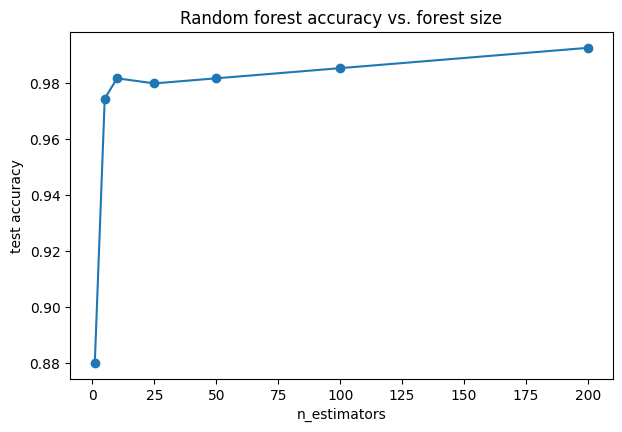

In [4]:
ns = [1, 5, 10, 25, 50, 100, 200]
accs = []
for n in ns:
    rf = RandomForestClassifier(
        n_estimators=n, max_depth=8, random_state=0,
    ).fit(X_tr, y_tr)
    accs.append(rf.score(X_te, y_te))

fig, ax = plt.subplots()
ax.plot(ns, accs, marker="o")
ax.set_xlabel("n_estimators")
ax.set_ylabel("test accuracy")
ax.set_title("Random forest accuracy vs. forest size")
plt.show()

## Takeaways

- On this dataset a small forest (25-50 trees) already gives
  top accuracy; further trees just cost compute.
- Random forests benefit most from feature subsampling
  (`max_features="sqrt"`), which decorrelates the trees.
- Compared to a single tree, the forest is far more
  **stable**: changing the random seed barely changes the
  output.